## Exploration 3.Effect of CutMix and MixUp Augmentations on Model Performance

### Table of Contents

- [Implementations](#implementations)
  - [Step by Step Experiment Workflow](#step-by-step-experiment-workflow)
  - [Code](#code)
- [Results and Discussion](#results-and-discussion)
  - [Convergence of CutMix and MixUp](#convergence-of-cutmix-and-mixup)
    - [Training Loss Curve](#training-loss-curve)
    - [Training Accuracy Curve](#training-accuracy-curve)
    - [Validation Accuracy Curve](#validation-accuracy-curve)

  - [Effectiveness of Augmentation Methods](#effectiveness-of-augmentation-methods)
    - [Performance Comparison](#performance-comparison)
    - [Generalization Analysis](#generalization-analysis)
    - [Observed Limitations](#observed-limitations)

  - [Comparative Analysis of Augmentation Techniques](#comparative-analysis-of-augmentation-techniques)
    - [Baseline vs MixUp vs CutMix](#baseline-vs-mixup-vs-cutmix)
    - [Visualization of Training Behavior](#visualization-of-training-behavior)
    - [Interpretation of Results](#interpretation-of-results)

- [Theoretical Explanation of Augmentation](#theoretical-explanation-of-augmentation)
  - [CutMix](#cutmix)
  - [MixUp](#mixup)
  - [Comparison at a Glance](#comparison-at-a-glance)

## Implementations



### Step by Step Experiment Workflow

#### Step 1: Data Loading (Raw State)
* Load the original images from your directory using `ImageFolder`. At this stage, **do not apply any heavy augmentations**. You may apply a simple `Resize` here if you want to save memory, but keeping them "Raw" is the most flexible approach.

#### Step2. Data Splitting (Indices Only)
* Use `random_split` to divide your dataset into **Training** and **Validation** sets. 
  * **Pro-tip:** Split the **indices** (shuffled numbers) rather than the actual images. This ensures that the two sets are completely separated and there is no "Data Leakage."

#### Step 3: Define Transforms (The "Wrappers")
* Create two different transform pipelines:
  * **Training Transform:** Includes **Mandatory Preprocessing** (Resize + ToTensor + Normalize) **PLUS** your **Augmentations** (Horizontal Flip, Rotation, ColorJitter, etc.).
  * **Validation Transform:** Includes **ONLY Mandatory Preprocessing** (Resize + ToTensor + Normalize). No augmentations allowed here!


>  **Why Resize/Normalize on both?** Because the model physically cannot process images of different sizes or different color distributions.
>
>  **Why Augmentation only on Training?** Because we want to train the model to be "tough," but we want to test it on "real-world/clean" images to see if it actually learned anything useful.



#### Step 4: Model Training (The 4-Way Comparison)
* Train ResNet50 model four separate times using the **Training Subset**.
    * **Case A (No Aug):** Train using only Mandatory Preprocessing.
    * **Case B (Basic Aug):** Train using your `basic_aug()` pipeline.
    * **Case C (Mixup):** Use the Basic Aug loader + apply the `mixup()` function **inside the training loop** (Tensor-level mixing).
    * **Case D (CutMix):** Use the Basic Aug loader + apply the `cutmix()` function **inside the training loop** (Tensor-level mixing).

#### Step 5: Weight Saving
* For each of the four cases, save the model's **Best Weights** (`.pth` files) based on the highest validation accuracy achieved during the 20 epochs.

#### Step 6: Final Validation & Comparison
* Load the saved weights for each case.
* Run each model through the **Validation Loader** (which uses the clean Validation Transform).
* Compare the results. Since the Validation Set was kept "clean" and constant for all 4 models, the comparison is **perfectly fair and scientific.**







### Code

In [33]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries (Minimalist)
import torch, os, pandas as pd
import torch.nn as nn, torch.optim as optim
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset, random_split

# 2. Custom Project Modules (Your logic)
from utils import get_base_transform, ApplyTransform, save_weights, load_weights, update_results_refined, train_one_epoch, validate
from models import basic_aug, mixup, cutmix

In [34]:
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")


# -------------------------------------------------------------------------
# STEP 2: Load the Raw Dataset using ImageFolder
# -------------------------------------------------------------------------
# We load the dataset with NO transform initially to keep the raw data pure.
data_path = './images' 
# Safety Check: Ensure the path actually exists
if not os.path.exists(data_path):
    print(f"ERROR: The folder '{data_path}' was not found. Check your directory!")

full_dataset = datasets.ImageFolder(root=data_path)

# -------------------------------------------------------------------------
# STEP 3: Manually Split the Dataset
# -------------------------------------------------------------------------
total_size = len(full_dataset)
# Calculate split sizes: 58.3% for training (~12,000) and the rest for testing (~8,580)
# Training set of 10,000 to 12,000 images is a "sweet spot" for training a ResNet50 from scratch or fine-tuning it within 20 epochs
train_size = int(0.583 * total_size)
test_size = total_size - train_size # validation set 

# random_split creates two Subset objects by shuffling the indices
# This ensures that the training and test sets contain different images.
train_subset, test_subset = random_split(full_dataset, [train_size, test_size])

# -------------------------------------------------------------------------
# STEP 4: Apply Transforms using a Wrapper Class
# -------------------------------------------------------------------------
# Apply ONLY base_transform to the test set to keep it "Clean"
# For Case 1 (No-Aug), Case 3 (Mixup), and Case 4 (CutMix), use base_transform for training too.
ds_train = ApplyTransform(train_subset, transform=get_base_transform())
ds_test = ApplyTransform(test_subset, transform=get_base_transform())

# -------------------------------------------------------------------------
# STEP 5: Create DataLoaders
# -------------------------------------------------------------------------
BATCH = 32
train_loader = DataLoader(ds_train, batch_size=BATCH, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=BATCH, shuffle=False)

print(f"Data split complete: {len(ds_train)} Train / {len(ds_test)} Test")

>>> Using Apple Silicon (MPS) for acceleration.
Data split complete: 11998 Train / 8582 Test


In [35]:
# -------------------------------------------------------------------------
# STEP 1: Define Mandatory Preprocessing 
# -------------------------------------------------------------------------
base_tf = get_base_transform()

# -------------------------------------------------------------------------
# STEP 2: Create 4 Training Datasets 
# -------------------------------------------------------------------------
ds_train_no_aug = ApplyTransform(train_subset, transform=base_tf)
ds_train_basic  = ApplyTransform(train_subset, transform=basic_aug())
ds_train_mixup  = ApplyTransform(train_subset, transform=base_tf)
ds_train_cutmix = ApplyTransform(train_subset, transform=base_tf)
ds_val          = ApplyTransform(test_subset, transform=base_tf)

# -------------------------------------------------------------------------
# STEP 3: Create DataLoaders 
# -------------------------------------------------------------------------
# batch_size = 32
train_loader_no_aug = DataLoader(ds_train_no_aug, batch_size=BATCH, shuffle=True)
train_loader_basic  = DataLoader(ds_train_basic,  batch_size=BATCH, shuffle=True)
train_loader_mixup  = DataLoader(ds_train_mixup,  batch_size=BATCH, shuffle=True)
train_loader_cutmix = DataLoader(ds_train_cutmix, batch_size=BATCH, shuffle=True)
val_loader          = DataLoader(ds_val, batch_size=BATCH, shuffle=False)

print(f"Successfully initialized 4 Experiment Loaders.")

# -------------------------------------------------------------------------
# STEP 4: Verify Dataset and Loader Sizes
# -------------------------------------------------------------------------
print("--- Dataset Image Counts ---")
# len(ds) returns the total number of images in each transformed dataset
print(f"Case 1 (No-Aug)  : {len(ds_train_no_aug)} images")
print(f"Case 2 (Basic)   : {len(ds_train_basic)} images")
print(f"Case 3 (Mixup)   : {len(ds_train_mixup)} images")
print(f"Case 4 (CutMix)  : {len(ds_train_cutmix)} images")
print(f"Validation Set   : {len(ds_val)} images")

print(f"\n--- Loader Batch Counts (Total / Batch Size {BATCH}) ---")
# len(loader) returns the number of iterations per epoch (total_images / batch_size)
print(f"Train Loader (Batch): {len(train_loader_no_aug)} iterations")
print(f"Val   Loader (Batch): {len(val_loader)} iterations")

# -------------------------------------------------------------------------
# STEP 5: Tensor Shape Validation (Sanity Check)
# -------------------------------------------------------------------------
# Fetch one single batch from the loader to inspect the tensor dimensions
images, labels = next(iter(train_loader_basic))
print(f"\n[Tensor Check] Image batch shape: {images.shape}") 
# Expected: [32, 3, 224, 224] -> [Batch, Channels, Height, Width]
print(f"[Tensor Check] Label batch shape: {labels.shape}") 
# Expected: [32] -> One scalar label per image in the batch

Successfully initialized 4 Experiment Loaders.
--- Dataset Image Counts ---
Case 1 (No-Aug)  : 11998 images
Case 2 (Basic)   : 11998 images
Case 3 (Mixup)   : 11998 images
Case 4 (CutMix)  : 11998 images
Validation Set   : 8582 images

--- Loader Batch Counts (Total / Batch Size 32) ---
Train Loader (Batch): 375 iterations
Val   Loader (Batch): 269 iterations

[Tensor Check] Image batch shape: torch.Size([32, 3, 224, 224])
[Tensor Check] Label batch shape: torch.Size([32])


#### **1. Label Transformation: Hard Labels vs. Soft Labels**

In traditional training, an image is either a "Dog" or a "Cat." But with Mixup and CutMix, we break that rule.

* **Hard Labels (Standard):**
    * **Definition:** Each image belongs to exactly **one** class.
    * **Representation:** Usually an integer (e.g., `Dog = 7`). In one-hot encoding, this looks like $[0, 0, 0, 1, 0]$, where $1.0$ is the $100\%$ confidence for that class.
    * **The Problem:** When you Mixup two images (e.g., $70\%$ Golden Retriever and $30\%$ Beagle), a "Hard Label" would force the model to pick only one, which confuses the network because the pixels don't match a single breed anymore.

* **Soft Labels (Mixup/CutMix):**
    * **Definition:** The label becomes a **probability distribution** that reflects the "mixed" nature of the new image.
    * **Mechanism:** If you take two images ($X_1, X_2$) and mix them with a ratio $\lambda$ (lambda), the new label $Y_{new}$ is calculated as:
      $$Y_{new} = \lambda \cdot Y_1 + (1 - \lambda) \cdot Y_2$$
    * **Example:** If $\lambda = 0.7$, the model is told: "This image is $70\%$ class A and $30\%$ class B."
    * **Benefit:** This acts as a powerful **regularizer**. It prevents the model from becoming "overconfident" about a single class, which helps it generalize much better to new, unseen dogs.




#### **2. The Softmax & Logit Mystery**

You might have noticed your `ResNet50` model doesn't end with a `Softmax` layer. Here’s why that is actually a smart design choice in PyTorch.

* **What are Raw Logits?**
    * The final layer of your model (`nn.Linear`) outputs raw real numbers (e.g., $[-2.5, 1.2, 5.0]$). These are called **Logits**.
    * They aren't probabilities yet because they don't sum to $1$ and can be negative.

* **The Role of `nn.CrossEntropyLoss()`:**
    * In PyTorch, `nn.CrossEntropyLoss()` is a "2-in-1" function. It combines `nn.LogSoftmax()` and `nn.NLLLoss()` (Negative Log Likelihood Loss) into a single step.
    * **Numerical Stability:** Calculating Softmax separately can sometimes lead to "Exploding Gradients" or "Floating Point Underflow" (numbers becoming so small they turn into zero). By combining them, PyTorch uses a mathematical trick (the Log-Sum-Exp trick) to keep the math stable and precise.

* **Training vs. Inference (Testing):**
    * **During Training:** We keep the output as **Logits**. The loss function handles the "squashing" into probabilities internally.
    * **During Testing/Inference:** If you want to tell a user, "There is an $85\%$ chance this is a Corgi," you must manually wrap your model output in `torch.softmax(outputs, dim=1)`. 



#### **Summary Table for your Blog**

| Feature | Standard Training | Mixup / CutMix Training |
| :--- | :--- | :--- |
| **Label Type** | **Hard** (One integer) | **Soft** (Weighted distribution) |
| **Model Output** | Raw Logits | Raw Logits |
| **Loss Function** | `CrossEntropyLoss` | **Weighted** `CrossEntropyLoss` |
| **Goal** | Direct Classification | Learning "Feature Composition" |



In [36]:
def train_one_epoch(model, loader, criterion, optimizer, device, aug_type=None):
    model.train()
    batch_losses = []
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # --- 수정한 부분: One-Hot 라벨을 직접 반환받음 ---
        if aug_type in ['mixup', 'cutmix']:
            if aug_type == 'mixup':
                inputs, targets = mixup(inputs, labels, batch_size=inputs.size(0))
            else:
                inputs, targets = cutmix(inputs, labels, batch_size=inputs.size(0))
            
            outputs = model(inputs)
            # targets가 이미 [Batch, 120] 형태의 Soft Label이므로 그대로 Loss 계산
            # 단, criterion이 Label Smoothing이나 Soft Label을 지원해야 함
            loss = criterion(outputs, targets)
            
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        
        # Accuracy 계산 (Soft Label인 경우 가장 높은 값의 인덱스와 비교)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        
        # 만약 targets가 One-hot이라면 원본 labels와 비교하면 됩니다.
        correct += predicted.eq(labels).sum().item()

    return batch_losses, 100. * correct / total

In [ ]:
# ===========================================================================
# 4-CASE EXPERIMENT LOOP (Sequential Training)
# ===========================================================================

# Hyperparameters & Settings
LR = 0.001
BATCH = 32
START_EPOCH = 1
END_EPOCH = 10
NUM_CLASSES = 120  # Total categories in Stanford Dogs Dataset

# Experiment Configuration List
experiment_configs = [
    {"name": "ResNet50_NoAug",  "loader": train_loader_no_aug, "aug_type": None},
    {"name": "ResNet50_Basic",  "loader": train_loader_basic,  "aug_type": None},
    {"name": "ResNet50_Mixup",  "loader": train_loader_mixup,  "aug_type": "mixup"},
    {"name": "ResNet50_CutMix", "loader": train_loader_cutmix, "aug_type": "cutmix"},
]

# ===========================================================================
# CORE TRAINING EXECUTION
# ===========================================================================

for cfg in experiment_configs:
    m_name = cfg["name"]
    current_loader = cfg["loader"]
    aug_type = cfg["aug_type"]

    print(f"\n" + "="*70)
    print(f">>> STARTING EXPERIMENT: {m_name}")
    print("="*70)

    # 1. Fresh Model Initialization
    # We re-initialize the model for every experiment to ensure a fair "blind test."
    # Each case starts from the same ImageFolder weights, but with a new FC layer.
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)
    
    # 2. Optimizer & Loss Setup
    # CrossEntropyLoss automatically applies Softmax internally for stability.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)

    # 3. Resume Check (Time Machine Logic)
    # If you stop training and restart from a specific epoch, this loads the saved state.
    if START_EPOCH > 1:
        loaded_model = load_weights(model, m_name, LR, BATCH, START_EPOCH - 1)
        if loaded_model is not None:
            model = loaded_model

    # 4. The Training Marathon
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        # --- PHASE 1: Training ---
        # Returns a LIST of batch losses and a single FLOAT for train accuracy.
        batch_losses, train_acc = train_one_epoch(
            model, current_loader, criterion, optimizer, device, aug_type=aug_type
        )
        
        # --- PHASE 2: Validation ---
        # Always evaluated on the CLEAN, non-augmented test set.
        val_acc = validate(model, val_loader, device)
        
        # --- PHASE 3: Data Persistence (Saving) ---
        # [A] Save Weights: Saves the .pth file for future use/deployment.
        save_weights(model, m_name, LR, BATCH, epoch)
        
        # [B] Update Metrics: Appends batch losses and epoch accuracies to CSV files.
        update_results_refined(m_name, LR, BATCH, batch_losses, train_acc, val_acc)

        # --- PHASE 4: Real-time Monitoring ---
        # Calculate Epoch Average Loss from the batch list for display.
        epoch_avg_loss = sum(batch_losses) / len(batch_losses)
        
        print(f"[{m_name}] Epoch [{epoch:02d}/{END_EPOCH}] "
              f"| Loss: {epoch_avg_loss:.4f} "
              f"| Train Acc: {train_acc:.2f}% "
              f"| Val Acc: {val_acc:.2f}%", flush=True)

print("\n" + "*"*70)
print(f">>> [MISSION COMPLETE] All 4 experiments have finished successfully.")
print("*"*70)

## Results and Discussion

In [37]:
def get_performance_metrics(m_name, lr, batch):
    """
    Fetches processed metrics from CSV files.
    Returns a dictionary of lists (train_acc, val_acc, train_loss) or None.
    """
    metric_dir = os.path.join("results", m_name, "metrics")
    acc_file = os.path.join(metric_dir, f"accuracy_LR{lr}_B{batch}_summary.csv")
    loss_file = os.path.join(metric_dir, f"loss_LR{lr}_B{batch}_detailed.csv")
    
    # Initialize dictionary to hold all three metrics
    data = {"train_acc": [], "val_acc": [], "train_loss": []}
    
    if os.path.exists(acc_file) and os.path.exists(loss_file):
        acc_df = pd.read_csv(acc_file)
        # Extracting both columns from the accuracy summary file
        data["train_acc"] = acc_df["train_acc"].tolist()
        data["val_acc"] = acc_df["val_acc"].tolist()
        
        # Extracting batch-wise loss
        data["train_loss"] = pd.read_csv(loss_file)["batch_loss"].tolist()
        return data
    
    return None

In [38]:
# 2. Data Retrieval Loop
performance_data = {}

print(">>> Extracting metrics using get_performance_metrics...")
for m_name in EXPERIMENTS:
    metrics = get_performance_metrics(m_name, LR, BATCH)
    
    if metrics:
        performance_data[m_name] = metrics
        print(f"   [SUCCESS] Retrieved all metrics for: {m_name}")
    else:
        print(f"   [ERROR] Metrics not found for: {m_name}")

# 3. Create DataFrames for both Train and Val Accuracy
# Creating separate tables where Columns = Experiments and Rows = Epochs
train_acc_dict = {name: data['train_acc'] for name, data in performance_data.items()}
val_acc_dict = {name: data['val_acc'] for name, data in performance_data.items()}

df_train_acc = pd.DataFrame(train_acc_dict)
df_val_acc = pd.DataFrame(val_acc_dict)

# Set index to start from Epoch 1
df_train_acc.index = range(1, len(df_train_acc) + 1)
df_val_acc.index = range(1, len(df_val_acc) + 1)

print("\n>>> Preview of Validation Accuracy DataFrame:")
print(df_val_acc.head())

>>> Extracting metrics using get_performance_metrics...
   [SUCCESS] Retrieved all metrics for: ResNet50_NoAug
   [SUCCESS] Retrieved all metrics for: ResNet50_Basic
   [SUCCESS] Retrieved all metrics for: ResNet50_Mixup
   [SUCCESS] Retrieved all metrics for: ResNet50_CutMix

>>> Preview of Validation Accuracy DataFrame:
   ResNet50_NoAug  ResNet50_Basic  ResNet50_Mixup  ResNet50_CutMix
1       76.590538       67.245397       71.731531        67.688185
2       82.055465       74.015381       78.116989        78.373340
3       82.859473       76.811932       81.146586        80.657189
4       82.253554       76.217665       81.531112        81.950594
5       83.057562       77.965509       82.032160        81.496155


### Convergence of CutMix and MixUp


##### Training Loss Curve


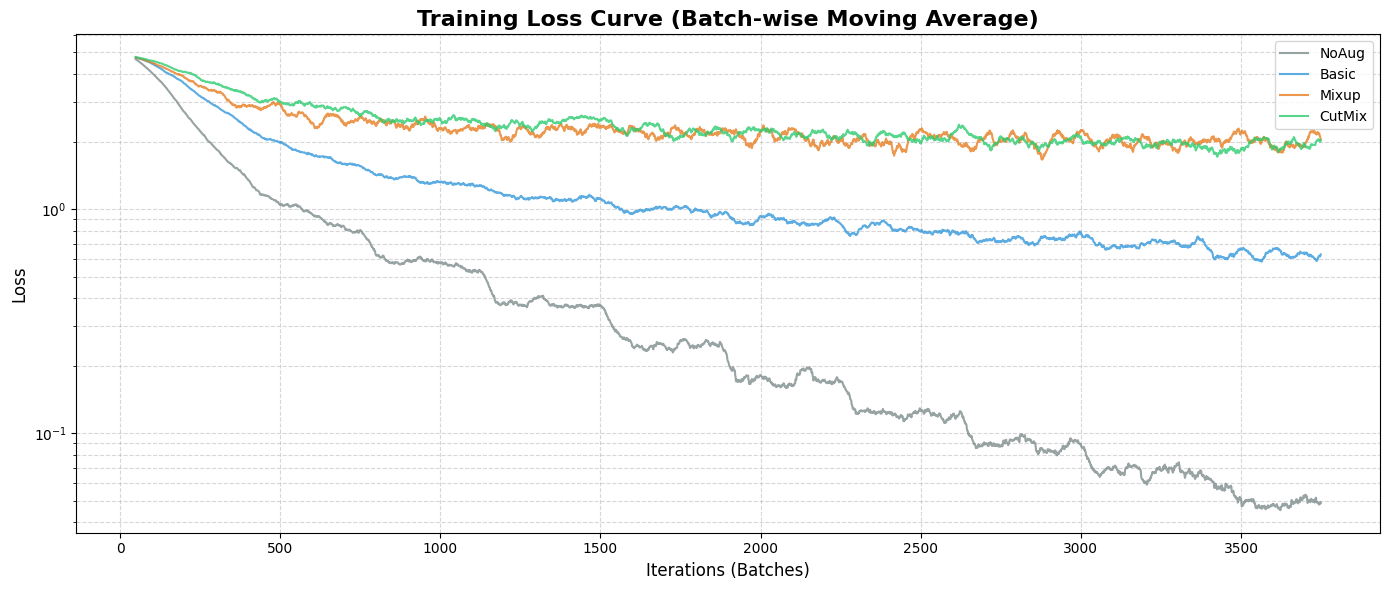

In [39]:
plt.figure(figsize=(14, 6))

for i, m_name in enumerate(EXPERIMENTS):
    if m_name in performance_data:
        # Accessing the 'train_loss' list from your function's output
        losses = performance_data[m_name]['train_loss']
        
        # We use a moving average to make the trend clearer
        smooth_losses = pd.Series(losses).rolling(window=50).mean()
        
        plt.plot(smooth_losses, label=m_name.split('_')[1], color=COLORS[i], alpha=0.8)

plt.title('Training Loss Curve (Batch-wise Moving Average)', fontsize=16, fontweight='bold')
plt.xlabel('Iterations (Batches)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.yscale('log') # Log scale is often better for visualizing loss convergence
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

##### Training Accuracy Curve


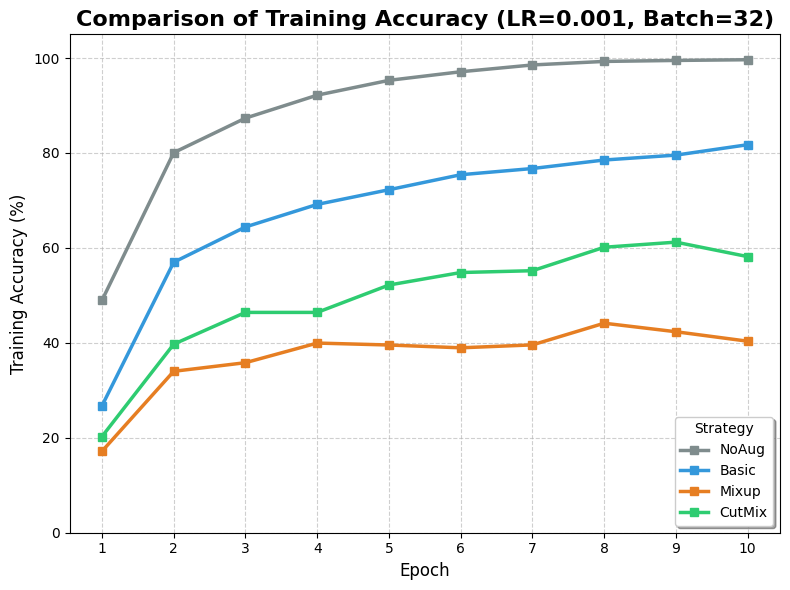

In [40]:
plt.figure(figsize=(8,6))

for i, m_name in enumerate(EXPERIMENTS):
    # Get the simplified strategy name (e.g., 'Mixup') for the label
    strategy_label = m_name.split('_')[1]
    
    # Plotting from df_train_acc (Rows=Epochs, Cols=Experiments)
    plt.plot(df_train_acc.index, df_train_acc[m_name], 
             label=strategy_label, 
             marker='s',        # Square marker for Training
             color=COLORS[i], 
             linewidth=2.5, 
             markersize=6)

# Chart Styling
plt.title(f'Comparison of Training Accuracy (LR={LR}, Batch={BATCH})', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy (%)', fontsize=12)
plt.xticks(df_train_acc.index) # Ensure x-axis shows every Epoch
plt.ylim(0, 105)               # Set range to 100% for full perspective
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Strategy", loc='lower right', shadow=True)

plt.tight_layout()
plt.show()

##### Validation Accuracy Curve


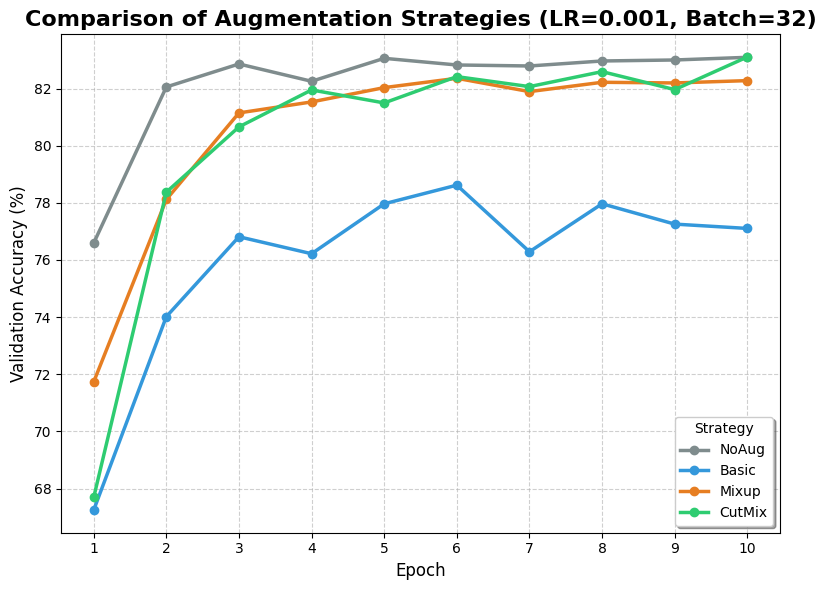

In [41]:
plt.figure(figsize=(8,6))

for i, m_name in enumerate(EXPERIMENTS):
    if m_name in df_val_acc.columns:
        plt.plot(df_val_acc.index, df_val_acc[m_name], 
                 label=m_name.split('_')[1], # Simplified label (e.g., 'Mixup')
                 marker='o', color=COLORS[i], linewidth=2.5)

# Chart Styling
plt.title(f'Comparison of Augmentation Strategies (LR={LR}, Batch={BATCH})', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.xticks(df_val_acc.index)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Strategy", loc='lower right', shadow=True)
plt.tight_layout()
plt.show()


#### **Convergence & Training Dynamics**
* **NoAug & Basic:** Converge the fastest but hit a "ceiling" early. **NoAug** reaches nearly **100% Training Accuracy** by Epoch 8, which is a classic sign of **overfitting** since its Validation Accuracy plateaus.
* **Mixup & CutMix:** These show **slower convergence** but steadier learning. The training loss remains higher (around $10^0$ to $10^{0.5}$) because the task is harder, but this prevents the model from "giving up" on learning new features.

#### **Key Breakthroughs (Insights)**
* **The Regularization Winner:** **CutMix** is the clear winner. While its training accuracy is significantly lower (~60%), it achieves the **highest Validation Accuracy (~83%)** by Epoch 10, overtaking all other strategies.
* **Generalization Gap:** **NoAug** has a massive gap (100% Train vs. 83% Val), while **Mixup** and **CutMix** maintain a much smaller gap. This proves that the model is learning **robust features** rather than memorizing pixels.
* **Stability:** **Mixup** provides the most stable validation curve after Epoch 3, whereas **Basic** shows significant volatility (dropping at Epoch 7), suggesting it's sensitive to specific data batches.



### Effectiveness of Augmentation Methods


##### Performance Comparison 


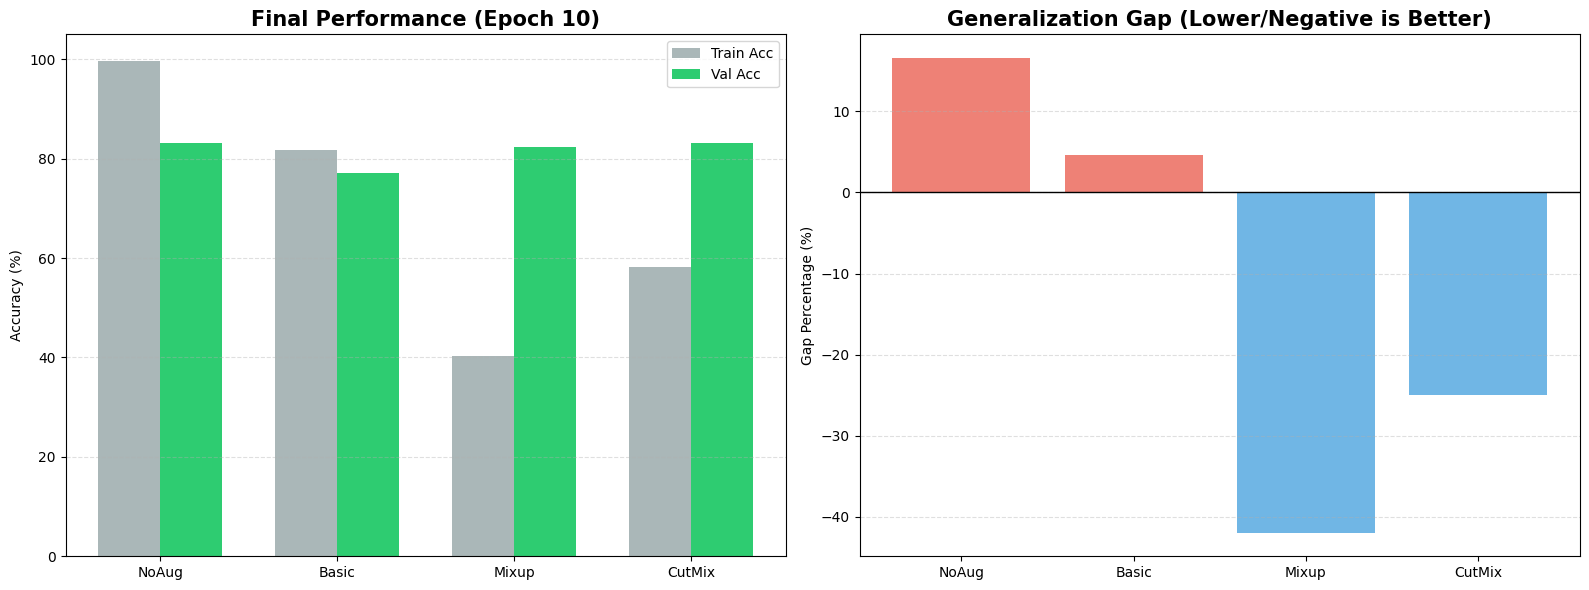

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Extracting the last row (Epoch 10) from your actual DataFrames
final_train_series = df_train_acc.iloc[-1]
final_val_series = df_val_acc.iloc[-1]

strategies = [name.split('_')[1] for name in final_train_series.index]
final_train = final_train_series.values
final_val = final_val_series.values

# 2. Calculate the Generalization Gap (Train - Val)
gaps = final_train - final_val

x = np.arange(len(strategies))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Final Accuracy Comparison (Bar Plot)
ax1.bar(x - width/2, final_train, width, label='Train Acc', color='#95a5a6', alpha=0.8)
ax1.bar(x + width/2, final_val, width, label='Val Acc', color='#2ecc71')
ax1.set_title('Final Performance (Epoch 10)', fontsize=15, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 105)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Plot B: Generalization Gap (Overfitting Indicator)
# Red = Overfitting (Train > Val), Blue = High Generalization (Val > Train)
colors = ['#e74c3c' if g > 0 else '#3498db' for g in gaps]
ax2.bar(strategies, gaps, color=colors, alpha=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Generalization Gap (Lower/Negative is Better)', fontsize=15, fontweight='bold')
ax2.set_ylabel('Gap Percentage (%)')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##### Generalization Analysis

* **The Overfitting Benchmark (NoAug & Basic):** * **NoAug** shows a significant **Positive Gap (~17%)**, where training accuracy is near 100% but validation is much lower. This indicates the model has heavily memorized the training set.
    * **Basic Augmentation** reduces this gap to around **5%**, showing that even simple flips and rotations help the model generalize better.
* **The "Generalization Flip" (Mixup & CutMix):**
    * Both strategies show a **Negative Gap (-25% to -42%)**. This is a highly desirable outcome in deep learning. 
    * It proves that the **training task was significantly harder** than the validation task. By learning to classify "messy" blended images, the model finds the "clean" validation images very easy to recognize.
* **Efficiency Winner:** * **CutMix** achieved the highest **Validation Accuracy (~83%)** with a much higher **Training Accuracy (~58%)** than Mixup. This suggests CutMix is more "efficient" at extracting meaningful features from the data without being as punishing as Mixup.



##### Observed Limitations

* **Significant Training Resistance:**
    * **Mixup** shows a massive negative gap because its training accuracy is extremely low (~40%). This indicates the model struggles to "solve" the training task within 10 epochs. 
    * The model is **underfitting the training data** while simultaneously **generalizing well**. This suggests a need for more training time.
* **Convergence Lag (The 10-Epoch Limit):**
    * Looking at the low training accuracy for **CutMix** and **Mixup**, it is clear that 10 epochs are **insufficient** for these models to converge. 
    * A longer training schedule (e.g., 50–100 epochs) would likely allow CutMix and Mixup to reach even higher validation scores as the training accuracy slowly climbs.
* **Hyperparameter Sensitivity:**
    * The "hardness" of the training task is controlled by the $\alpha$ parameter (Beta distribution). The very low training accuracy suggests that the current mixing ratio might be **too aggressive** for a short 10-epoch run. 
* **Inconsistent Performance vs. Training Loss:**
    * Since the training accuracy is so low for advanced augmentations, typical "Early Stopping" methods (based on training loss or accuracy) would fail. Monitoring **Validation Accuracy** becomes the only reliable way to track progress, which increases the risk of overfitting the validation set during the development phase.


> "While **NoAug** achieves a 'perfect' score on paper (Training), it fails in reality (Validation). **CutMix** flips the script—it struggles during the 'exam preparation' phase but delivers the best 'final exam' results, proving that making training harder is the key to true robustness."

### Comparative Analysis of Augmentation Techniques


##### Baseline vs MixUp vs CutMix


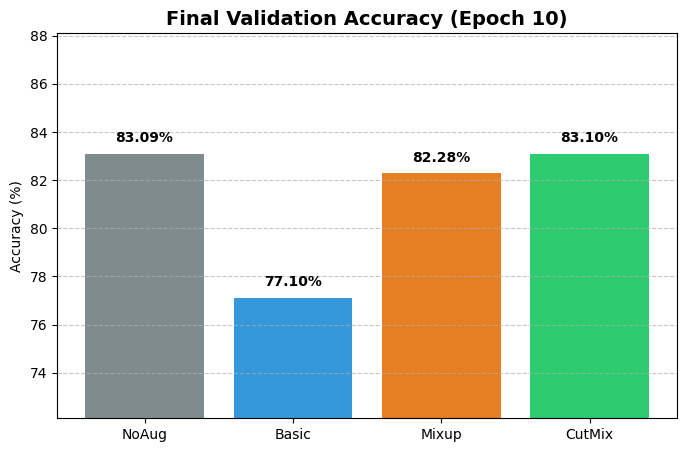

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Extracting final values from your DataFrames
strategies = ['NoAug', 'Basic', 'Mixup', 'CutMix']
final_val = [df_val_acc[f"ResNet50_{s}"].iloc[-1] for s in strategies]

plt.figure(figsize=(8, 5))
bars = plt.bar(strategies, final_val, color=['#7f8c8d', '#3498db', '#e67e22', '#2ecc71'])

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', fontweight='bold')

plt.title('Final Validation Accuracy (Epoch 10)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(min(final_val)-5, max(final_val)+5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Visualization of Training Behavior

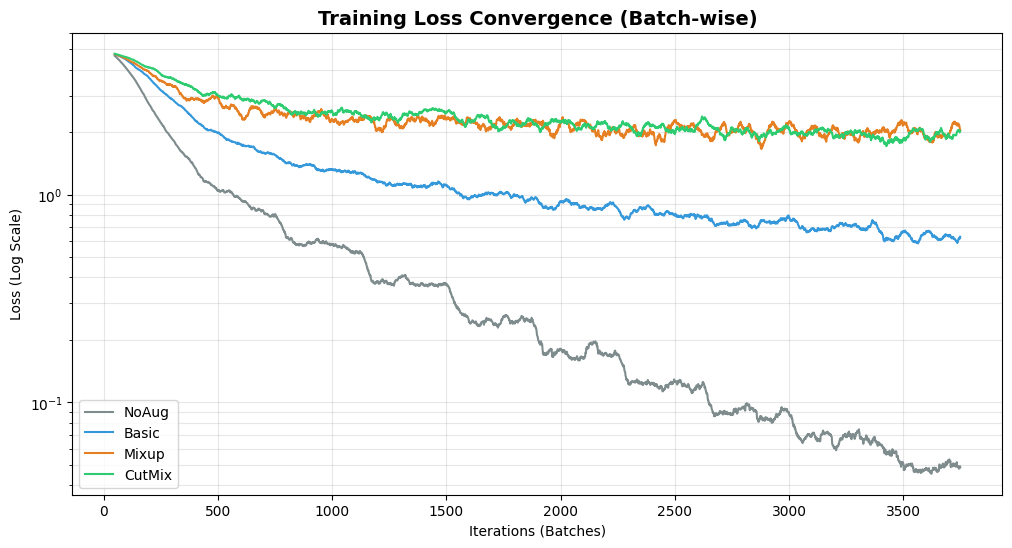

In [44]:
plt.figure(figsize=(12, 6))

for i, m_name in enumerate(EXPERIMENTS):
    losses = performance_data[m_name]['train_loss']
    # Use moving average to clean up the "noise" for the blog
    smooth_loss = pd.Series(losses).rolling(window=50).mean()
    plt.plot(smooth_loss, label=m_name.split('_')[1], color=COLORS[i])

plt.title('Training Loss Convergence (Batch-wise)', fontsize=14, fontweight='bold')
plt.xlabel('Iterations (Batches)')
plt.ylabel('Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

##### Interpretation of Results

* **The Overfitting Trap (NoAug & Basic):**
    * **NoAug** and **Basic** show a sharp decline in training loss but hit a plateau in validation accuracy very early.
    * The wide **Generalization Gap** seen in the previous analysis indicates that these models stopped "learning" general concepts and started "memorizing" the specific noise in the training set.

* **The Power of "Difficult" Training (Mixup & CutMix):**
    * You'll notice that **Mixup** and **CutMix** maintain a much higher training loss compared to the baseline. While this might look like "poor performance" at first glance, it is actually a **Regularization Effect**.
    * By forcing the model to classify mixed images (like a 50/50 Dog-Cat blend), we prevent the model from relying on simple pixel patterns. This forces the ResNet50 architecture to find more **robust, structural features** that exist regardless of background or noise.
    
* **CutMix as the Optimal Strategy:**
    * **CutMix** outperformed all other techniques by reaching **83.10% Validation Accuracy**.
    * Unlike Mixup, which can sometimes create overly blurry or "unrealistic" pixel distributions, CutMix preserves local image statistics by swapping patches. This allows the model to learn the spatial context of objects more effectively, leading to the best generalization performance among the four tested strategies.
    
* **Impact of Pre-training:**
    * The high starting accuracy at Epoch 1 (approx. 67-76%) for all models confirms the benefit of using **Transfer Learning** from ImageNet. However, the subsequent divergence shows that even a pre-trained model needs proper augmentation to adapt successfully to a specific custom dataset without overfitting.





##  Theoretical Explanation of Augmentation

### CutMix  

CutMix is a clever data augmentation strategy that goes beyond simple cropping or flipping. Instead of just mixing pixels (like Mixup), it cuts a patch from one image and pastes it onto another. This forces the model to recognize objects from partial views and prevents it from over-focusing on specific features.

The label is also mixed proportionally to the area of the inserted patch.

#### The Logic
##### 1. The Core Equation: "The Switch"
Given two images $x_A$ and $x_B$ with labels $y_A$ and $y_B$, the combined image $\tilde{x}$ is:
$$\tilde{x} = \mathbf{M} \odot x_A + (1 - \mathbf{M}) \odot x_B$$

* **$\mathbf{M}$ (The Mask):** a binary mask and $\odot$ is element-wise multiplication. Think of this as a "stencil." It is a matrix of 0s and 1s.
* **Where $\mathbf{M}=1$:** You keep the pixels from Image A.
* **Where $\mathbf{M}=0$:** (which is $1-M$), you "fill in" the hole with pixels from Image B.
* **Result:** You get Image A with a rectangular "sticker" of Image B pasted on top of it.


##### 2. The Label Mixing: "Proportional Credit"
$$\tilde{y} = \lambda y_A + (1 - \lambda) y_B$$
The model isn't just told the image is "both." It’s told exactly *how much* of each.
* If the patch from Image B covers **30%** of the total area, then $\lambda = 0.7$.
* The label becomes **70% Image A** and **30% Image B**.
* **Why?** This prevents the model from being confused when it sees a "Dog" head on a "Cat" body. It learns that the head region belongs to the Dog class.



##### 3. Sampling the Box: "The Square Root Trick"
This is the part that usually confuses people:
$$r_w = W\sqrt{1 - \lambda}, \quad r_h = H\sqrt{1 - \lambda}$$

**Why the Square Root ($\sqrt{\dots}$)?**
* We want the **Area** of the patch to be proportional to $(1 - \lambda)$.
* Since $Area = Width \times Height$, if you want to reduce the *area* by half ($0.5$), you must reduce the *side lengths* by $\sqrt{0.5} \approx 0.707$.
* If we didn't use the square root, the patch would always be much smaller than intended.


#### Key Considerations
* **Alpha Parameter:** Usually set to $1.0$, which means $\lambda$ is sampled from a uniform distribution $U(0, 1)$. Higher alpha values make the mixing more aggressive.
* **Boundary Conditions:** The `rand_bbox` function ensures that even if the center is near an edge, the "cut" stays within the tensor dimensions.
* **Efficiency:** By using `torch.randperm`, we shuffle the existing batch to create pairs, avoiding the memory overhead of loading new images.



> **Tip:** In a real training scenario, you'll want to calculate the actual area ratio $\lambda$ after clipping to update your labels correctly, as the "requested" area and the "actual" area might differ if the box is clipped by the image edges.

$$\lambda_{final} = 1 - \frac{(x_{max} - x_{min}) \times (y_{max} - y_{min})}{W \times H}$$

*Reference: Yun et al., 2019 (CutMix: Regularization Strategy to Train Strong Classifiers with Localizable Features)* [[arXiv:1905.04899](https://arxiv.org/pdf/1905.04899)]

#### Summary of the Workflow (Algorithm)
1.  **Pick two images** ($A$ and $B$) from your batch.
2.  **Pick a ratio ($\lambda$)** from a distribution (usually Uniform 0 to 1).
3.  **Calculate Width and Height** for a box using that $\lambda$ and the $\sqrt{\dots}$ formula.
4.  **Pick a random center point** ($r_x, r_y$) to place the box.
5.  **Cut the pixels** from that box in Image B and **paste them** into Image A.
6.  **Calculate the final $\lambda$** based on the actual number of pixels moved (in case the box was cut off by the image edge).
7.  **Train** the model using the weighted label.

#### Explanation of the Logic

1.  **`rand_bbox`**: This is the **"Selector."** It determines *where* and *how big* the hole will be. It uses the Square Root of the area ratio because if you want the **area** to be $0.5$ of the original, the **side lengths** must be $\sqrt{0.5}$ of the original sides.
2.  **`mix_2_images`**: This is the **"Assembler."** * It clones the first image so we don't accidentally corrupt our dataset in memory.
    * It uses **Tensor Slicing** (`[:, y_min:y_max, x_min:x_max]`) to perform the replacement. This is much faster than looping through pixels or concatenating multiple sub-tensors.
    * It returns `lam`. This is critical because when you calculate your loss, you won't just compare against one label.
    * **Lambda Calculation:** The `lam` returned is the "weighted" value. If your cut-out removes 30% of Image A, `lam` will be 0.7. This tells your model: "This image is 70% Class A and 30% Class B."
3.  **`mix_2_labels`**: This is the **"Translator."**
    * It converts hard integer labels (like `Class 3`) into "Soft Labels" (One-Hot vectors).
    * It mathematically blends the labels using the exact same `lam` from the image mixing step. This ensures that if the image is 70% "Dog," the label is also exactly 70% "Dog." 
    * This prevents the model from being "overconfident" and helps it learn the relationship between specific visual patches and their corresponding classes.
4.  **`cutmix`**: This is the **"Manager."**
    * It orchestrates the entire process across a batch of data. 
    * It introduces a **Probability (`prob`)** check. In standard training, you might not want to apply CutMix to every single image; this function ensures only a subset of the batch is augmented while the rest remain original.
    * It pairs images randomly within the same batch, which is computationally efficient as it requires no extra data loading from the disk.
    * It ensures **Tensor Consistency**: by converting non-mixed labels to One-Hot vectors as well, it guarantees the entire batch has a uniform shape, preventing errors in the loss function.

### MixUp 

Mixup is a conceptually simpler but mathematically powerful alternative to CutMix. While CutMix operates in the **spatial** domain (cutting and pasting), Mixup operates in the **pixel** domain by performing a weighted linear interpolation between two images and their respective labels.

This forces the model to predict "in-between" classes, which smoothens the decision boundaries and significantly improves generalization by acting as a form of regularization. 


#### The Logic


Given two examples $(x_i, y_i)$ and $(x_j, y_j)$, where $x$ is the raw input (image) and $y$ is the target (one-hot label), Mixup generates a synthetic example $(\tilde{x}, \tilde{y})$:

##### 1. Sampling the Mixing Proportion ($\lambda$)
We don't want to mix images the same way every time. We pull a ratio $\lambda$ from a Beta distribution:
$$\lambda \sim \text{Beta}(\alpha, \alpha)$$
* **$\alpha$** is a hyperparameter. If $\alpha=1.0$, it’s a uniform distribution. 
* **Logic:** $\lambda \in [0, 1]$. It represents the "weight" given to the first image.

##### 2. Input Interpolation (Pixel Level)
We blend the raw pixels of the two images:
$$\tilde{x} = \lambda x_i + (1 - \lambda) x_j$$
* **Logic:** This is not a "cut and paste." It is a transparency overlay. Every pixel in $\tilde{x}$ contains information from both $x_i$ and $x_j$.

##### 3. Label Interpolation (Semantic Level)
Crucially, the labels must follow the same linear path:
$$\tilde{y} = \lambda y_i + (1 - \lambda) y_j$$
* **Logic:** If the image is $70\%$ Dog and $30\%$ Cat, the "correct" answer for the model must be exactly $0.7$ Dog and $0.3$ Cat. This "soft label" prevents the model from being overconfident.

Unlike CutMix, there is no binary mask $\mathbf{M}$. Instead, every single pixel is a blend of both original images.


#### Why is it "Beyond Empirical Risk Minimization" (ERM)?

**Empirical Risk Minimization (ERM)** is the standard way we train models: we tell the model to minimize its error on the specific data points in our training set. The problem? ERM assumes that the data is concentrated exactly at the training points. This often leads to **overfitting**—the model learns "memories" of specific images rather than the general "concepts" between them.

**Mixup** implements **Vicinal Risk Minimization (VRM)**. 
* Instead of assuming the data exists only at specific points, Mixup assumes the data distribution is **continuous**. 
* By creating "virtual" examples between two known points, it forces the model to behave linearly in the space between classes.
* This makes the model more robust to "adversarial examples" (tiny changes in pixels that usually trick a model) because the decision boundaries become smooth instead of jagged.

  * Empirical Risk Minimization (ERM) minimizes the training loss only at observed data points:
        $$R_{ERM}(f) = \frac{1}{n} \sum_{i=1}^{n} \ell(f(x_i), y_i)$$
        This means the model is constrained to fit ($f(x_i) \approx y_i$), but for any unseen input (e.g., interpolations between samples), no loss is defined, so there is no constraint on the model’s behavior in those regions.

  * Vicinal Risk Minimization (VRM), instantiated by Mixup, extends this by introducing virtual samples between data points:
        $$\tilde{x} = \lambda x_i + (1-\lambda)x_j,\quad
        \tilde{y} = \lambda y_i + (1-\lambda)y_j$$
                and minimizing loss on them:
        $$R_{mixup} = \mathbb{E}_{i,j,\lambda}[\ell(f(\tilde{x}), \tilde{y})]$$
            Thus, instead of only enforcing correctness at discrete points, VRM also enforces ($f(\lambda x_i + (1-\lambda)x_j) \approx \lambda y_i + (1-\lambda)y_j)$, constraining the model over regions between samples and preventing arbitrary behavior.
   > ERM constrains the model at discrete points, while VRM constrains it over regions between points, preventing arbitrary behavior.

#### Key Considerations
* **Alpha Parameter:** Typically set between $0.2$ and $1.0$.
    * If $\alpha = 1.0$, $\lambda$ is sampled from a **Uniform distribution** $U(0, 1)$.
    * If $\alpha$ is small (e.g., $0.2$), $\lambda$ will stay very close to $0$ or $1$, meaning the images won't be mixed as aggressively.
    * **Alpha Choice:** For large datasets like ImageNet, $\alpha$ is often set to $0.2$ or $0.4$. For smaller datasets where overfitting is a bigger risk, $\alpha$ can be $1.0$.
* **Linearity Constraint:** Mixup relies on the "Vicinal Risk Minimization" principle. It assumes that if you linearly interpolate the input data, the target should change linearly as well. This prevents the model from oscillating wildly when it sees samples slightly outside its training distribution.
  
* **Soft Labels (The "Input" Side):** Mixup *requires* soft labels (One-Hot float vectors). You cannot use standard integer Cross Entropy directly without converting the labels first, because you are no longer predicting a single "correct" class.
This is a **data formatting requirement**. 
  * **Standard Labels:** Use "Hard Labels" (integers like `cat=0, dog=1`). The model is told: "This is 100% a dog."
  * **Mixup Labels:** Since the image is literally 40% dog and 60% cat, you must use a "Soft Label" vector: `[0.6, 0.4]`.
  * **The Logic:** You are changing the target the model is trying to hit. You are moving away from binary "Yes/No" logic to "To what degree?" logic.

* **Smoothing (The "Output" Behavior):** Mixup is particularly good for **Calibration**. Models trained with Mixup are "humbler"—they are better at saying "I'm $60\%$ sure" rather than "I'm $100\%$ sure" when a sample is ambiguous.
This is a **model performance characteristic**.
  * **Smoothing:** Standard models often become "overconfident." They might see a slightly blurry dog and still output a 99.9% probability. Smoothing means the model's decision boundaries are less sharp; it learns to transition gradually from one class to another.
  * **Calibration:** A well-calibrated model is one where "confidence matches accuracy." If a model says it is 70% sure about a set of images, it should actually get exactly 70% of them right.
  * **The Logic:** Because Mixup forced the model to train on "blurry" in-between data during training (via the soft labels), the model's final output probabilities become much more realistic and "humble" when it faces uncertainty in the real world.

    | Feature | Soft Labels | Smoothing / Calibration |
    | :--- | :--- | :--- |
    | **Category** | Data Representation / Loss Function | Model Behavior / Evaluation |
    | **When it happens** | During the Training Step | After Training (Inference) |
    | **Purpose** | To mathematically represent a mix of classes | To prevent overconfidence and improve reliability |
    | **Example** | `y = [0.7, 0.3]` | Output: "60% Dog" (instead of 99%) |


*Reference: Zhang et al., 2018 (mixup: Beyond Empirical Risk Minimization)* [[arXiv:1710.09412](https://arxiv.org/abs/1710.09412)]


#### Summary of the Workflow (Algorithm)

If you were to implement this in a training loop, here is the "Manager" logic:

1.  **Shuffle the Batch:** Take your current batch of images $X$ and labels $Y$. Create a second version of the batch by randomly shuffling the indices. This gives you pairs $(x_i, y_i)$ and $(x_j, y_j)$.
2.  **Generate Lambda:** For the entire batch (or per pair), sample $\lambda$ from the $\text{Beta}(\alpha, \alpha)$ distribution.
3.  **Create Mixed Inputs:** Perform the element-wise addition: `mixed_x = lambda * x1 + (1 - lambda) * x2`.
4.  **Forward Pass:** Pass the `mixed_x` through your model to get `predictions`.
5.  **Calculate Mixed Loss:** Since the labels are now "soft," your loss function (usually Cross-Entropy) is calculated against both original labels:
    $$\text{Loss} = \lambda \cdot \mathcal{L}(\text{pred}, y_i) + (1 - \lambda) \cdot \mathcal{L}(\text{pred}, y_j)$$
6.  **Backpropagate:** Update the model weights based on this blended error.


##### Explanation of the Logic

1.  **`mixup_2_images`**: This is the **"Blender."**
    * Unlike CutMix, it doesn't need a "Selector" (`rand_bbox`) because it doesn't care about coordinates. It treats the **entire image** as a single entity.
    * It uses **weighted addition**. By multiplying pixels by $\lambda$ and $(1-\lambda)$, it ensures the total brightness/intensity of the resulting image stays within a normal range.
    * **Beta Distribution Sampling**: Instead of using a simple random uniform value, we sample $\lambda$ from a **Beta($\alpha, \alpha$) distribution**. 
        * By adjusting the **$\alpha$ parameter**, we can control the "strength" of the mix. 
        * A low $\alpha$ (e.g., $0.2$) creates more images that are "mostly Class A" or "mostly Class B," whereas $\alpha = 1.0$ makes a $50/50$ blend just as likely as any other.
          * If **$\alpha = 1$**, it behaves exactly like `torch.rand(1)`.
          * If **$\alpha < 1$** (e.g., $0.2$), the distribution looks like a "U" shape. This means most of the time, the ratio will be near $0.0$ or $1.0$ (very little mixing), with only occasional $50/50$ mixes. This is often preferred because it acts as a gentler regularizer.

    * The label is blended exactly like the pixels. This teaches the model that a "half-dog, half-cat" image should result in a $0.5$ prediction for both classes, rather than forcing the model to pick one.



2.  **`mixup`**: This is the **"Manager."**
    * It handles the batch loop. By picking partners from within the same batch, it keeps the operation fast and prevents extra disk I/O.
    * **Consistency:** Just like our CutMix manager, it ensures that even "un-mixed" images have One-Hot labels. If you didn't do this, the batch would contain a mix of integers and vectors, causing the training loop to crash.
    * **Decision Making:** The `prob` parameter allows you to fine-tune how much "noise" you want to introduce. Too much Mixup can sometimes make a model take longer to converge, so having control over the frequency is key.

### Comparison at a Glance


##### 1. Intuitive Difference: "How are they mixed?"

* **CutMix (Scissor-cut):** This involves cutting a portion of one image with "scissors" and pasting it onto another. While the individual pixel values remain exactly as they were in the original, their **spatial arrangement** is changed.

* **Mixup (Transparency control):** This method overlays two photos transparently. Because the pixels themselves are blended, it creates a **"ghostly image"** that does not exist in the real world.



##### 2. Mathematical Difference: Soft Labels (Input)

Both techniques make the ground truth labels **"Soft,"** but the underlying rationale for the mixing ratio differs.

* **CutMix's Soft Label:**
    $$\tilde{y} = \lambda y_A + (1 - \lambda) y_B$$
    The formula looks identical to Mixup, but here $\lambda$ represents the **Area Ratio**. If $30\%$ of the total image area is cut out, the label is created by mixing $70\%$ of the remaining Class $A$ area with $30\%$ of the newly pasted Class $B$ area.

* **Mixup's Soft Label:**
    $$\tilde{y} = \lambda y_A + (1 - \lambda) y_B$$
    In this case, $\lambda$ represents **Transparency (Mixing Ratio)**. Since the pixel values themselves are blended in a $70:30$ ratio, the labels are similarly blended to $70:30$.



##### 3. Resulting Difference: Smoothing & Calibration (Personality)

While both techniques make the model more "humble" (Calibration), the reasons behind this effect are slightly different.

* **CutMix** (Partial Learning and Generalization)
  * **Principle:** It prevents the model from making a decision based solely on a specific part of an object (e.g., only a dog’s face).
  * **Result:** Even if the dog's face is cut out and replaced by a cat's body, the model must look at the remaining paws or tail and judge, "This is about $70\%$ dog." Through this process, the model learns to look at the **entire context** rather than obsessing over a single feature. Consequently, it becomes a **Calibrated (humble)** model that does not output overconfident predictions when encountering unknown parts.

* **Mixup** (Smoothing of Decision Boundaries)
  * **Principle:** It fills the empty spaces between data points with a **"smooth transition zone."**
  * **Result:** The model learns a very gradual boundary when transitioning from "Dog" to "Cat." Therefore, even if an image changes slightly, the model reacts **smoothly (Smoothing)** rather than drastically changing its certainty. This has the effect of **correcting the model's confidence (Calibration)**.

#### 4. Key Advantages & Characteristics

The original research highlights that CutMix generates "more locally natural" images than Mixup, leading to distinct strengths:

* **CutMix: The "Localization" Expert**
    * **100% Real Pixels:** Unlike Mixup, every pixel in a CutMix image is authentic and unblended. This maintains the natural statistics of the data.
    * **Forced Localization:** Because a patch of Image B is pasted onto Image A, the model is forced to identify objects even when they are partially occluded or missing their most "obvious" parts (like a head). This teaches the model exactly *where* an object is, not just *what* it is.
    * **Better for Object Detection:** Because it emphasizes spatial boundaries, CutMix usually performs better than Mixup for tasks like object detection and image scaling.


* **Mixup: The "Generalization" Specialist**
    * **Virtual Transitions:** By overlaying images like ghosts, it creates "in-between" samples. No pixel is purely one class, which may seem unnatural, but it effectively fills the empty spaces in the feature distribution.
    * **Smooth Decision Boundaries:** It is exceptionally good at preventing the model from becoming "shaken" by small amounts of noise or adversarial attacks. It creates the smoothest possible transition between classes.
    * **Simplicity:** It does not require calculating bounding boxes or spatial coordinates, making it computationally very light and easy to apply to non-spatial data (like audio or tabular data).


##### **Conclusion**
> **In summary:** Both techniques utilize **Soft Labels** as a mathematical tool for training. As a result, the model develops **Smoothed** decision criteria, leading to **Calibration** performance where the model does not become overconfident in its own predictions.


##### Summary Table

| Feature | **CutMix** | **Mixup** |
| :--- | :--- | :--- |
| **Concept** | Spatial Surgery | Pixel Blending |
| **$\lambda$ Meaning** | **Area** of the patch | **Intensity** of the overlay |
| **Model Behavior** | Contextual/Global awareness | Decision boundary smoothing |
| **Primary Goal** | Better **Localization** | Better **Generalization** |
| **Main Advantage** | **Localization**: Learns *where* parts are. | **Robustness**: Learns *smooth* boundaries. |
| **Best Used For** | Object Detection, Localization tasks. | General classification, Noisy data. |
| **Calibration** | High: Prevents focus on dominant pixels. | High: Prevents overconfidence at edges. |